# Extração 5 — Seleção de Atributos

**Entregável 9**

Seleção de features sobre `features_engineered.parquet` (antes do PCA, para manter interpretabilidade).

| Passo | Método | Propriedade |
|-------|--------|-------------|
| 1 | ANOVA F-test, Mutual Information, ReliefF | Filter — univariado/multivariado |
| 2 | LASSO (L1) | Embedded — caminho de regularização |
| 3 | Correção BH + Cohen's d | Controle de falsos positivos + tamanho de efeito |
| 4 | Ranking de consenso | Top-N features selecionadas |

**Input:** `data/silver/features_engineered.parquet`
**Output:** `data/silver/features_selecionadas.parquet`

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests
from scipy import stats
import matplotlib.pyplot as plt
import warnings, time

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})
rng = np.random.default_rng(42)

In [2]:
ROOT = Path('..')
FEAT_ENG_PATH = ROOT / 'data' / 'silver' / 'features_engineered.parquet'
OUT_PATH      = ROOT / 'data' / 'silver' / 'features_selecionadas.parquet'

df = pd.read_parquet(FEAT_ENG_PATH)
print(f'Dataset: {df.shape[0]:,} x {df.shape[1]}')

META_COLS = ['patient_id', 'task_label', 'janela_inicio_s']
meta_cols_present = [c for c in META_COLS if c in df.columns]
feat_cols = [c for c in df.columns if c not in meta_cols_present]

X_raw = df[feat_cols].values.astype(np.float64)
y     = df['task_label'].values.astype(int)
N_WIN, N_FEAT = X_raw.shape
print(f'  Features : {N_FEAT}')
print(f'  Janelas  : {N_WIN:,}  (label=0: {(y==0).sum():,}  label=1: {(y==1).sum():,})')

# Imputa NaN de bordas de delta com 0
X = np.where(np.isnan(X_raw), 0.0, X_raw)

N_TOP = int(np.floor(np.sqrt(N_WIN)))
print(f'  N_TOP (floor(sqrt(N_WIN))): {N_TOP}')

Dataset: 24,564 x 1373
  Features : 1370
  Janelas  : 24,564  (label=0: 14,386  label=1: 10,178)
  N_TOP (floor(sqrt(N_WIN))): 156


## Passo 1 — Métodos Filter

Três critérios complementares, aplicados independentemente sobre cada feature:

- **ANOVA F-test**: testa se a média de cada feature difere entre classes. Linear, rápido.
- **Mutual Information**: captura dependências não-lineares que ANOVA perde.
- **ReliefF** (subamostrado): considera interações — pondera features que separam instâncias
  de classes diferentes entre si, usando k vizinhos mais próximos. Especialmente útil para
  biossinais onde features correlacionadas carregam informação complementar.

In [3]:
print('ANOVA F-test...')
t0 = time.time()
F_vals, p_vals_raw = f_classif(X, y)
F_vals = np.nan_to_num(F_vals, nan=0.0, posinf=0.0)
p_vals_raw = np.nan_to_num(p_vals_raw, nan=1.0)

rank_anova    = np.argsort(-F_vals)
rank_pos_anova = np.empty(N_FEAT, dtype=np.int32)
rank_pos_anova[rank_anova] = np.arange(N_FEAT, dtype=np.int32)

print(f'  Concluido em {time.time() - t0:.1f}s')
print(f'  Top-5 por F-estatistico:')
for k in rank_anova[:5]:
    print(f'    [{rank_pos_anova[k]+1:4d}] {feat_cols[k][:60]:<60s}  F={F_vals[k]:.2f}')

ANOVA F-test...
  Concluido em 0.4s
  Top-5 por F-estatistico:
    [   1] LShank-GYRO-Z__time__VAR                                      F=13562.77
    [   2] LShank-GYRO-Z__time__MAV                                      F=13488.32
    [   3] LShank-GYRO-Y__time__RMS                                      F=9040.51
    [   4] LShank-GYRO-Y__time__VAR                                      F=8922.44
    [   5] LShank-GYRO-Z__time__ZCR                                      F=7168.88


In [4]:
print('Mutual Information...')
t0 = time.time()
mi_vals = mutual_info_classif(X, y, n_neighbors=5, random_state=42)

rank_mi    = np.argsort(-mi_vals)
rank_pos_mi = np.empty(N_FEAT, dtype=np.int32)
rank_pos_mi[rank_mi] = np.arange(N_FEAT, dtype=np.int32)

print(f'  Concluido em {time.time() - t0:.1f}s')
print(f'  Top-5 por MI:')
for k in rank_mi[:5]:
    print(f'    [{rank_pos_mi[k]+1:4d}] {feat_cols[k][:60]:<60s}  MI={mi_vals[k]:.5f}')

Mutual Information...
  Concluido em 99.6s
  Top-5 por MI:
    [   1] LShank-GYRO-Z__time__VAR                                      MI=0.26978
    [   2] LShank-GYRO-Z__time__MAV                                      MI=0.23841
    [   3] LShank-GYRO-Y__time__VAR                                      MI=0.22424
    [   4] LShank-GYRO-Z__freq__band_movimento__delta2                   MI=0.19675
    [   5] LShank-GYRO-Z__freq__band_movimento                           MI=0.19482


In [5]:
print('ReliefF (subamostrado, simplificado)...')
t0 = time.time()

N_SAMPLE    = min(2000, N_WIN)
K_NEIGH     = 10
N_ITER_RF   = min(200, N_SAMPLE)

idx_s  = rng.choice(N_WIN, size=N_SAMPLE, replace=False)
X_s    = X[idx_s].astype(np.float32)
y_s    = y[idx_s]

# Normaliza para [0,1] — obrigatorio para a metrica de diferenca do ReliefF
x_min   = X_s.min(axis=0)
x_range = np.maximum(X_s.max(axis=0) - x_min, 1e-12)
X_n     = (X_s - x_min) / x_range

cls0 = np.where(y_s == 0)[0]
cls1 = np.where(y_s == 1)[0]

weights  = np.zeros(N_FEAT, dtype=np.float64)
iter_idx = rng.choice(N_SAMPLE, size=N_ITER_RF, replace=False)

for i in iter_idx:
    xi   = X_n[i]
    yi   = y_s[i]
    same  = cls0[cls0 != i] if yi == 0 else cls1[cls1 != i]
    other = cls1 if yi == 0 else cls0
    if len(same) == 0 or len(other) == 0:
        continue
    k_h = min(K_NEIGH, len(same))
    k_m = min(K_NEIGH, len(other))
    d_h = np.abs(X_n[same]  - xi).sum(axis=1)
    d_m = np.abs(X_n[other] - xi).sum(axis=1)
    hit_idx  = same[np.argsort(d_h)[:k_h]]
    miss_idx = other[np.argsort(d_m)[:k_m]]
    weights -= np.abs(X_n[hit_idx]  - xi).mean(axis=0)
    weights += np.abs(X_n[miss_idx] - xi).mean(axis=0)

weights /= N_ITER_RF

rank_relief    = np.argsort(-weights)
rank_pos_relief = np.empty(N_FEAT, dtype=np.int32)
rank_pos_relief[rank_relief] = np.arange(N_FEAT, dtype=np.int32)

print(f'  Concluido em {time.time() - t0:.1f}s  '
      f'({N_ITER_RF} iteracoes, {N_SAMPLE} amostras, k={K_NEIGH})')
print(f'  Top-5 por ReliefF:')
for k in rank_relief[:5]:
    print(f'    [{rank_pos_relief[k]+1:4d}] {feat_cols[k][:60]:<60s}  w={weights[k]:.6f}')

ReliefF (subamostrado, simplificado)...
  Concluido em 1.4s  (200 iteracoes, 2000 amostras, k=10)
  Top-5 por ReliefF:
    [   1] LShank-GYRO-Z__time__MAV                                      w=0.092206
    [   2] LShank-GYRO-Z__time__VAR                                      w=0.076470
    [   3] LShank-GYRO-Y__time__RMS                                      w=0.070584
    [   4] LShank-GYRO-Y__time__VAR                                      w=0.054219
    [   5] LShank-GYRO-Z__time__ZCR                                      w=0.035281


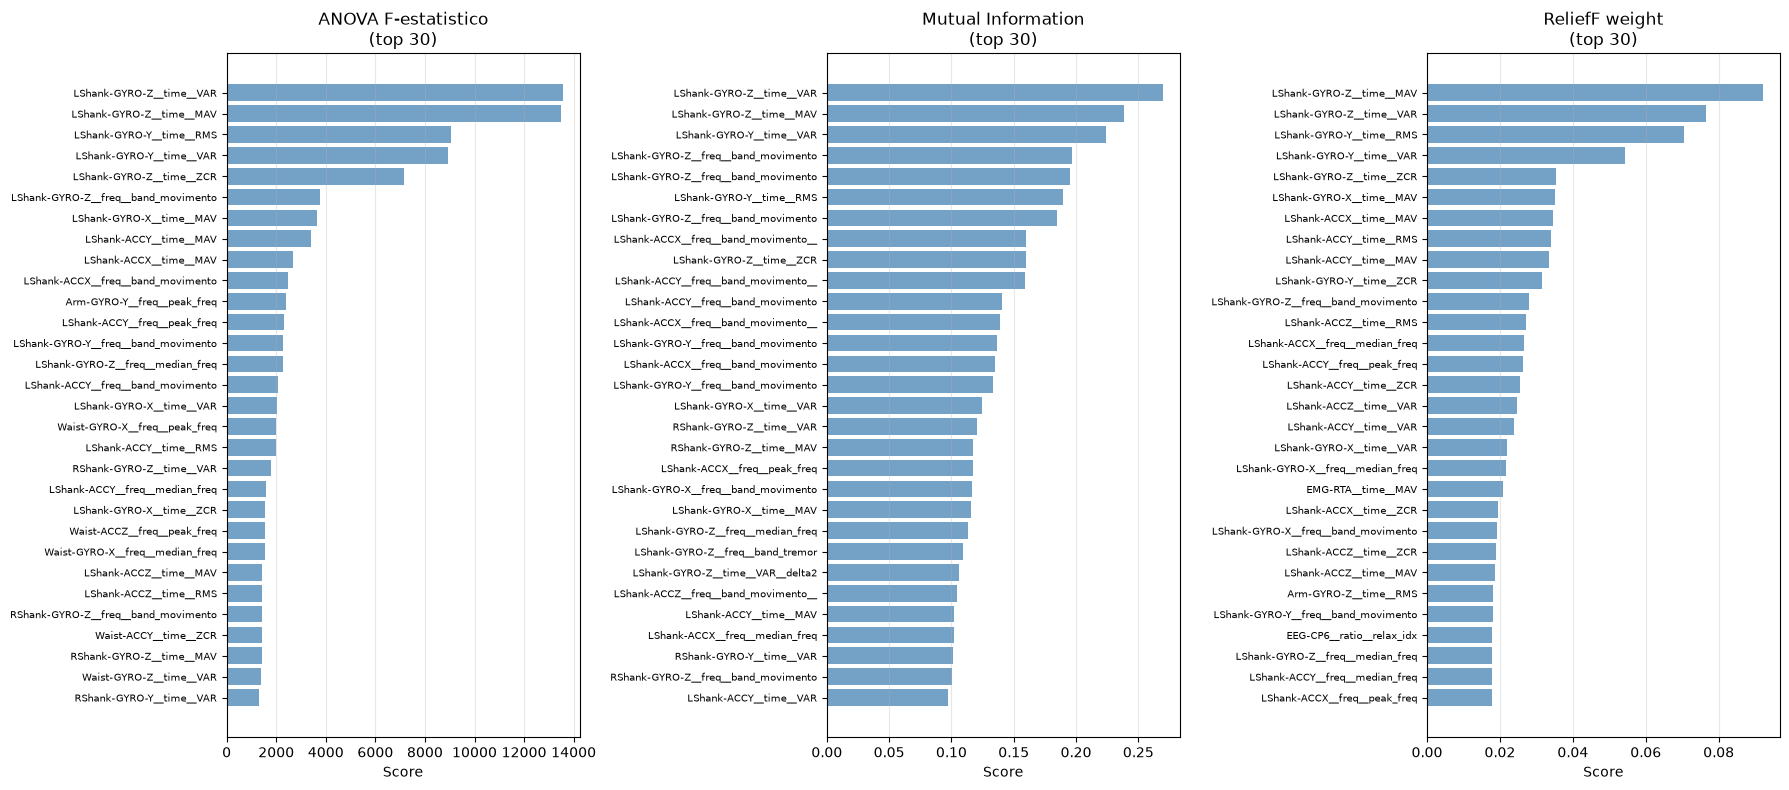

Salvo em data/silver/filter_methods_top30.png


In [6]:
TOP_SHOW = 30
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, vals, title, rank_ord in [
    (axes[0], F_vals,   'ANOVA F-estatistico',  rank_anova),
    (axes[1], mi_vals,  'Mutual Information',   rank_mi),
    (axes[2], weights,  'ReliefF weight',       rank_relief),
]:
    top_idx  = rank_ord[:TOP_SHOW]
    top_vals = vals[top_idx]
    top_lbl  = [feat_cols[j][:35] for j in top_idx]
    ax.barh(range(TOP_SHOW), top_vals[::-1], alpha=0.75, color='steelblue')
    ax.set_yticks(range(TOP_SHOW))
    ax.set_yticklabels(top_lbl[::-1], fontsize=7)
    ax.set_title(f'{title}\n(top {TOP_SHOW})')
    ax.set_xlabel('Score')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'silver' / 'filter_methods_top30.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Salvo em data/silver/filter_methods_top30.png')

## Passo 2 — LASSO (Método Embedded)

Regressão logística com penalidade L1 (`penalty='l1'`).
O parâmetro `C = 1/λ` controla a força da regularização:

- **C pequeno** (alta regularização): apenas features muito informativas sobrevivem com
  coeficiente ≠ 0.
- **C grande** (baixa regularização): quase todas as features ficam ativas.

A **ordem de entrada** no modelo (ao aumentar C) determina o ranking de importância LASSO.
Usamos subconjunto de 5 000 janelas para velocidade — suficiente para o ranking relativo.

In [7]:
print('LASSO — caminho de regularizacao...')

N_LASSO  = min(5000, N_WIN)
C_VALS   = np.logspace(-3, 0, 15)   # forte -> fraca regularizacao
idx_l    = rng.choice(N_WIN, size=N_LASSO, replace=False)
X_l_raw  = X[idx_l]
y_l      = y[idx_l]

scaler_l  = StandardScaler()
X_l       = scaler_l.fit_transform(X_l_raw)
coef_path = np.zeros((len(C_VALS), N_FEAT), dtype=np.float32)

t0 = time.time()
for j, C in enumerate(C_VALS):
    lr = LogisticRegression(penalty='l1', C=float(C), solver='liblinear',
                            max_iter=300, random_state=42)
    lr.fit(X_l, y_l)
    coef_path[j] = lr.coef_[0]
    n_nz = int((coef_path[j] != 0).sum())
    print(f'  C={C:.4f}: {n_nz:4d} features ativas')

print(f'Concluido em {time.time() - t0:.1f}s')

# Ranking LASSO: features que entraram primeiro (maior C minimo para ser ativo)
first_active = np.full(N_FEAT, len(C_VALS))   # index em C_VALS em que virou != 0
for j in range(len(C_VALS)):
    newly = (coef_path[j] != 0) & (first_active == len(C_VALS))
    first_active[newly] = j

rank_lasso     = np.argsort(first_active)     # menor indice = entrou com menos features
rank_pos_lasso = np.empty(N_FEAT, dtype=np.int32)
rank_pos_lasso[rank_lasso] = np.arange(N_FEAT, dtype=np.int32)

print(f'\nTop-5 por LASSO (entraram primeiro):')
for k in rank_lasso[:5]:
    print(f'    [{rank_pos_lasso[k]+1:4d}] {feat_cols[k][:60]:<60s}  '
          f'entrada em C={C_VALS[first_active[k]]:.4f}')

LASSO — caminho de regularizacao...
  C=0.0010:    2 features ativas
  C=0.0016:    3 features ativas
  C=0.0027:    5 features ativas
  C=0.0044:   14 features ativas
  C=0.0072:   29 features ativas
  C=0.0118:   54 features ativas
  C=0.0193:   95 features ativas
  C=0.0316:  147 features ativas
  C=0.0518:  214 features ativas
  C=0.0848:  301 features ativas
  C=0.1389:  419 features ativas
  C=0.2276:  542 features ativas
  C=0.3728:  696 features ativas
  C=0.6105:  820 features ativas
  C=1.0000:  925 features ativas
Concluido em 31.7s

Top-5 por LASSO (entraram primeiro):
    [   1] LShank-GYRO-Z__time__MAV                                      entrada em C=0.0010
    [   2] LShank-GYRO-Z__time__VAR                                      entrada em C=0.0010
    [   3] LShank-GYRO-Z__time__ZCR                                      entrada em C=0.0016
    [   4] LShank-GYRO-Y__time__VAR                                      entrada em C=0.0027
    [   5] Waist-ACCY__time__ZCR        

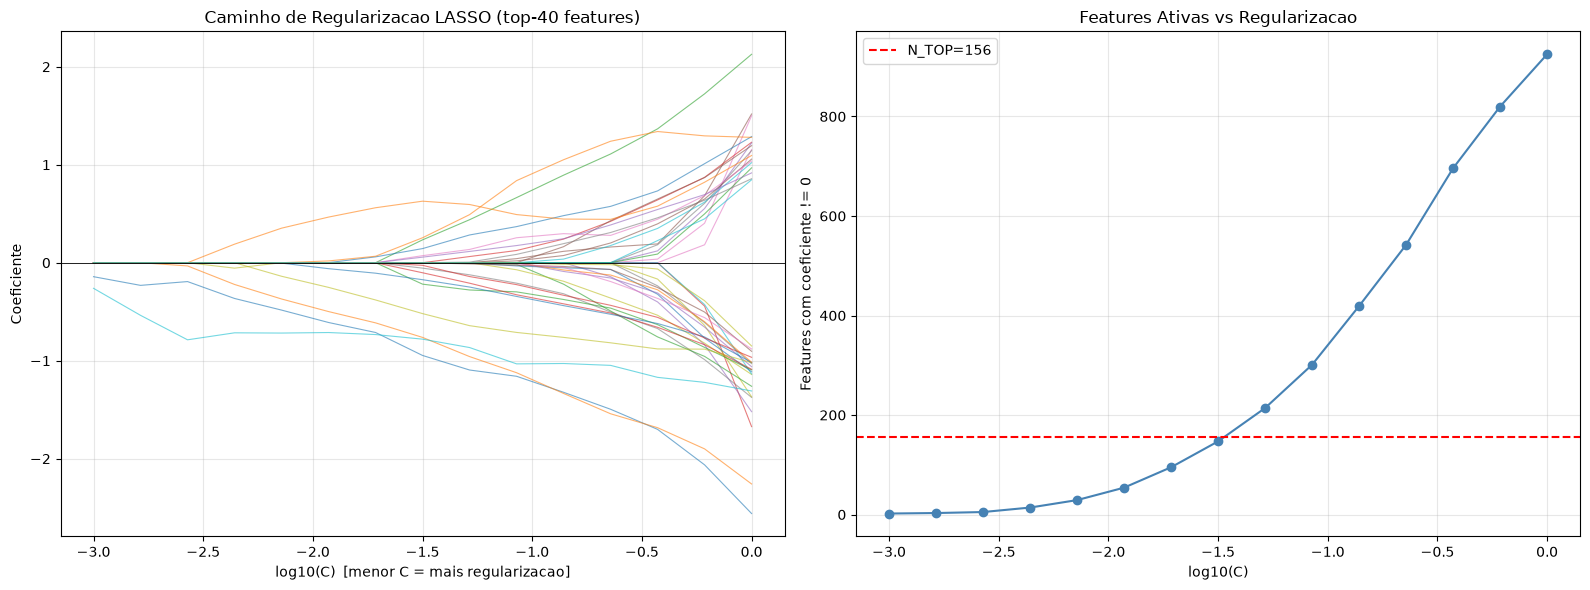

Salvo em data/silver/lasso_path.png


In [8]:
# Mostra apenas top-40 features (por magnitude final de coeficiente)
top40_idx = np.argsort(-np.abs(coef_path[-1]))[:40]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
for k in top40_idx:
    ax1.plot(np.log10(C_VALS), coef_path[:, k], linewidth=0.8, alpha=0.6)
ax1.axhline(0, color='black', linewidth=0.6)
ax1.set_xlabel('log10(C)  [menor C = mais regularizacao]')
ax1.set_ylabel('Coeficiente')
ax1.set_title('Caminho de Regularizacao LASSO (top-40 features)')
ax1.grid(alpha=0.3)

ax2 = axes[1]
n_active_per_C = (coef_path != 0).sum(axis=1)
ax2.plot(np.log10(C_VALS), n_active_per_C, 'o-', color='steelblue')
ax2.axhline(N_TOP, color='red', linestyle='--', label=f'N_TOP={N_TOP}')
ax2.set_xlabel('log10(C)')
ax2.set_ylabel('Features com coeficiente != 0')
ax2.set_title('Features Ativas vs Regularizacao')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'silver' / 'lasso_path.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo em data/silver/lasso_path.png')

## Passo 3 — Correção FDR + Tamanho de Efeito

Com centenas de features, testar cada uma individualmente gera muitos falsos positivos.
A correção de **Benjamini-Hochberg (BH)** controla a *False Discovery Rate* (FDR):
a fração esperada de rejeições incorretas entre todas as rejeições ≤ 5%.

**Cohen's d** quantifica o tamanho de efeito de forma independente do tamanho amostral:

```
d = (μ₁ − μ₀) / s_pooled
```

Interpretação: |d| < 0.2 trivial, 0.2–0.5 pequeno, 0.5–0.8 médio, > 0.8 grande.

In [9]:
print('Correcao de Benjamini-Hochberg (FDR)...')
reject_bh, p_bh, _, _ = multipletests(p_vals_raw, alpha=0.05, method='fdr_bh')
n_pass = int(reject_bh.sum())
print(f'  Features com p_bh < 0.05: {n_pass} / {N_FEAT}  ({100*n_pass/N_FEAT:.1f}%)')

print('Calculando Cohen\'s d...')
y0 = y == 0
y1 = y == 1
n0, n1 = int(y0.sum()), int(y1.sum())
m0, m1 = X[y0].mean(axis=0), X[y1].mean(axis=0)
s0, s1 = X[y0].std(axis=0, ddof=1), X[y1].std(axis=0, ddof=1)
s_pool  = np.sqrt(((n0 - 1) * s0**2 + (n1 - 1) * s1**2) / (n0 + n1 - 2))
cohens_d = (m1 - m0) / np.maximum(s_pool, 1e-12)

# Tabela resumo
summary_df = pd.DataFrame({
    'feature'      : feat_cols,
    'F_stat'       : F_vals,
    'p_raw'        : p_vals_raw,
    'p_bh'         : p_bh,
    'reject_bh'    : reject_bh,
    'cohens_d'     : cohens_d,
    'abs_cohens_d' : np.abs(cohens_d),
    'MI'           : mi_vals,
    'relief_w'     : weights,
    'rank_anova'   : rank_pos_anova,
    'rank_mi'      : rank_pos_mi,
    'rank_relief'  : rank_pos_relief,
    'rank_lasso'   : rank_pos_lasso,
})

print('\nTop-10 por F-estatistico (com BH e Cohen\'s d):')
top10 = summary_df.nlargest(10, 'F_stat')[
    ['feature', 'F_stat', 'p_bh', 'reject_bh', 'cohens_d']
]
print(top10.to_string(index=False))

# Distribuicao de Cohen's d
bins_d = [(-np.inf,-0.8),(-0.8,-0.5),(-0.5,-0.2),(-0.2,0.2),(0.2,0.5),(0.5,0.8),(0.8,np.inf)]
labels_d = ['<-0.8','[-0.8,-0.5)','[-0.5,-0.2)','[-0.2,0.2)','[0.2,0.5)','[0.5,0.8)','>=0.8']
print('\nDistribuicao de Cohen\'s d:')
for (lo, hi), lbl in zip(bins_d, labels_d):
    cnt = int(((cohens_d > lo) & (cohens_d <= hi)).sum())
    print(f'  {lbl:>12s}: {cnt:5d}')

Correcao de Benjamini-Hochberg (FDR)...
  Features com p_bh < 0.05: 849 / 1370  (62.0%)
Calculando Cohen's d...

Top-10 por F-estatistico (com BH e Cohen's d):
                            feature       F_stat  p_bh  reject_bh  cohens_d
           LShank-GYRO-Z__time__VAR 13562.774490   0.0       True -1.508421
           LShank-GYRO-Z__time__MAV 13488.319334   0.0       True -1.504275
           LShank-GYRO-Y__time__RMS  9040.506929   0.0       True -1.231529
           LShank-GYRO-Y__time__VAR  8922.443443   0.0       True -1.223461
           LShank-GYRO-Z__time__ZCR  7168.883036   0.0       True  1.096665
LShank-GYRO-Z__freq__band_movimento  3781.363482   0.0       True -0.796476
           LShank-GYRO-X__time__MAV  3629.567814   0.0       True -0.780325
             LShank-ACCY__time__MAV  3409.900102   0.0       True -0.756344
             LShank-ACCX__time__MAV  2687.085915   0.0       True -0.671412
  LShank-ACCX__freq__band_movimento  2486.086773   0.0       True -0.645812

Dis

## Passo 4 — Ranking de Consenso e Seleção Final

Para cada feature, soma-se as posições nos rankings de ANOVA, MI e ReliefF.
Features com **menor soma** são as mais consensualmente informativas pelos três critérios.

**Critério de N:** regra prática N < √n_janelas evita overfitting em classificadores
baseados em distância/regularização — mantemos as features com maior variância
explicada coletiva mas sem saturar o espaço.

N_TOP = floor(sqrt(24564)) = 156
Features selecionadas: 156

Top-15 por consenso ANOVA+MI+ReliefF:
  [  1] soma=     1  (A=1 M=1 R=2)  LShank-GYRO-Z__time__VAR
  [  2] soma=     2  (A=2 M=2 R=1)  LShank-GYRO-Z__time__MAV
  [  3] soma=     8  (A=4 M=3 R=4)  LShank-GYRO-Y__time__VAR
  [  4] soma=     9  (A=3 M=6 R=3)  LShank-GYRO-Y__time__RMS
  [  5] soma=    16  (A=5 M=9 R=5)  LShank-GYRO-Z__time__ZCR
  [  6] soma=    19  (A=6 M=5 R=11)  LShank-GYRO-Z__freq__band_movimento
  [  7] soma=    31  (A=7 M=21 R=6)  LShank-GYRO-X__time__MAV
  [  8] soma=    40  (A=8 M=26 R=9)  LShank-ACCY__time__MAV
  [  9] soma=    47  (A=16 M=16 R=18)  LShank-GYRO-X__time__VAR
  [ 10] soma=    49  (A=13 M=13 R=26)  LShank-GYRO-Y__freq__band_movimento
  [ 11] soma=    49  (A=9 M=36 R=7)  LShank-ACCX__time__MAV
  [ 12] soma=    52  (A=10 M=14 R=31)  LShank-ACCX__freq__band_movimento
  [ 13] soma=    61  (A=14 M=22 R=28)  LShank-GYRO-Z__freq__median_freq
  [ 14] soma=    67  (A=12 M=44 R=14)  LShank-ACCY__freq_

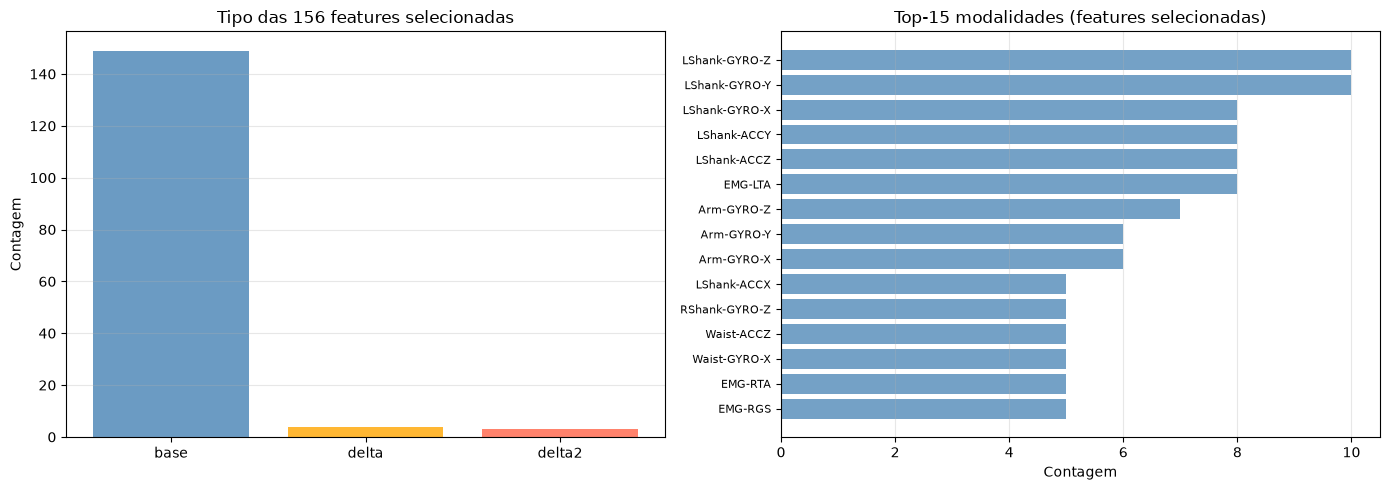

Salvo em data/silver/feature_selection_dist.png


In [10]:
rank_sum      = rank_pos_anova.astype(np.int64) + rank_pos_mi + rank_pos_relief
rank_consensus = np.argsort(rank_sum)

N_SELECT      = min(N_TOP, N_FEAT)
selected_idx  = rank_consensus[:N_SELECT]
selected_feats = [feat_cols[i] for i in selected_idx]

print(f'N_TOP = floor(sqrt({N_WIN})) = {N_TOP}')
print(f'Features selecionadas: {N_SELECT}')
print(f'\nTop-15 por consenso ANOVA+MI+ReliefF:')
for pos, i in enumerate(rank_consensus[:15]):
    print(f'  [{pos+1:3d}] soma={rank_sum[i]:6d}  '
          f'(A={rank_pos_anova[i]+1} M={rank_pos_mi[i]+1} R={rank_pos_relief[i]+1})  '
          f'{feat_cols[i][:55]}')

# Distribuicao das features selecionadas por tipo
tipos = {'base':0, 'delta':0, 'delta2':0}
for fname in selected_feats:
    if '__delta2' in fname:
        tipos['delta2'] += 1
    elif '__delta' in fname:
        tipos['delta'] += 1
    else:
        tipos['base'] += 1

modalidades = {}
for fname in selected_feats:
    mod = fname.split('__')[0] if '__' in fname else fname
    modalidades[mod] = modalidades.get(mod, 0) + 1

print(f'\nDistribuicao por tipo:  {tipos}')
print(f'Top modalidades:')
for mod, cnt in sorted(modalidades.items(), key=lambda x: -x[1])[:10]:
    print(f'  {mod:<20s}: {cnt}')

# Plot distribuicao
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.bar(tipos.keys(), tipos.values(), color=['steelblue','orange','tomato'], alpha=0.8)
ax1.set_title(f'Tipo das {N_SELECT} features selecionadas')
ax1.set_ylabel('Contagem')
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[1]
top_mods = sorted(modalidades.items(), key=lambda x: -x[1])[:15]
mods_lbl, mods_cnt = zip(*top_mods)
ax2.barh(range(len(mods_lbl)), mods_cnt[::-1], alpha=0.75, color='steelblue')
ax2.set_yticks(range(len(mods_lbl)))
ax2.set_yticklabels([m[:25] for m in mods_lbl[::-1]], fontsize=8)
ax2.set_title('Top-15 modalidades (features selecionadas)')
ax2.set_xlabel('Contagem')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'silver' / 'feature_selection_dist.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Salvo em data/silver/feature_selection_dist.png')

In [11]:
print(f'Salvando features_selecionadas.parquet ({N_SELECT} features)...')
df_sel = df[meta_cols_present + selected_feats].copy()
df_sel.to_parquet(OUT_PATH, index=False)
size_mb = OUT_PATH.stat().st_size / 1e6
print(f'  Salvo : {OUT_PATH}')
print(f'  Shape : {df_sel.shape[0]:,} x {df_sel.shape[1]}')
print(f'  Tamanho: {size_mb:.1f} MB')

rankings_path = ROOT / 'data' / 'silver' / 'feature_selection_rankings.parquet'
summary_df.to_parquet(rankings_path, index=False)
print(f'  Rankings completos: {rankings_path}')

print(f'\nResumo final:')
print(f'  Features originais : {N_FEAT}')
print(f'  Features selecionadas: {N_SELECT}  ({100*N_SELECT/N_FEAT:.1f}% retidas)')
print(f'  Criterio: floor(sqrt({N_WIN})) = {N_TOP}')
reject_sel = reject_bh[selected_idx].sum()
print(f'  Passam BH (p_bh<0.05): {reject_sel}/{N_SELECT}  ({100*reject_sel/N_SELECT:.1f}%)')
d_sel = np.abs(cohens_d[selected_idx])
print(f'  Cohen\'s |d| medio das selecionadas: {d_sel.mean():.3f}')
print(f'  Cohen\'s |d| > 0.5 (efeito medio+): {(d_sel > 0.5).sum()}')

Salvando features_selecionadas.parquet (156 features)...
  Salvo : ../data/silver/features_selecionadas.parquet
  Shape : 24,564 x 159
  Tamanho: 12.5 MB
  Rankings completos: ../data/silver/feature_selection_rankings.parquet

Resumo final:
  Features originais : 1370
  Features selecionadas: 156  (11.4% retidas)
  Criterio: floor(sqrt(24564)) = 156
  Passam BH (p_bh<0.05): 156/156  (100.0%)
  Cohen's |d| medio das selecionadas: 0.342
  Cohen's |d| > 0.5 (efeito medio+): 23


## Resumo — Entregável 9

| Item | Valor |
|------|-------|
| Features de entrada | `features_engineered.parquet` |
| Método 1 (filter) | ANOVA F-test |
| Método 2 (filter) | Mutual Information |
| Método 3 (filter) | ReliefF (200 iters, 2 000 amostras, k=10) |
| Método 4 (embedded) | LASSO regularization path (liblinear, 15 valores de C) |
| Correção múltiplas comparações | Benjamini-Hochberg FDR α=5% |
| Tamanho de efeito | Cohen's d por feature |
| Consenso | soma de posições ANOVA + MI + ReliefF |
| N selecionado | floor(√n\_janelas) |
| Saída | `features_selecionadas.parquet` |

**Próximo:** `classificação_1.ipynb` — LOSO cross-validation com as features selecionadas.